(sec:vib_spect)=
# Vibrational spectroscopies

VeloxChem provides simulations of vibrational spectroscopies by evaluating molecular force constants and deriving normal modes whose frequencies and transition properties form the basis for IR and Raman spectra. Building on a converged ground‑state DFT reference, the program computes the molecular Hessian and transforms it to mass‑weighted internal coordinates to obtain physically meaningful vibrational modes, while subsequent response‑theory evaluations yield dipole‑derivative and polarizability‑derivative quantities that determine vibrational intensities. Together, these capabilities enable predictions of both harmonic vibrational frequencies and their associated infrared and Raman signatures.

The calculation of normal modes is performed with the aid of [geomeTRIC](https://pypi.org/project/geometric/).

:::{note}
The associated IR spectrum is calculated by default also when Raman or resonance Raman calculations are requested.
:::

(sec:ir)=
## Infrared

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("formaldehyde")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = True

vib_results = vib_drv.compute(molecule, basis)

Reading formaldehyde from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct I

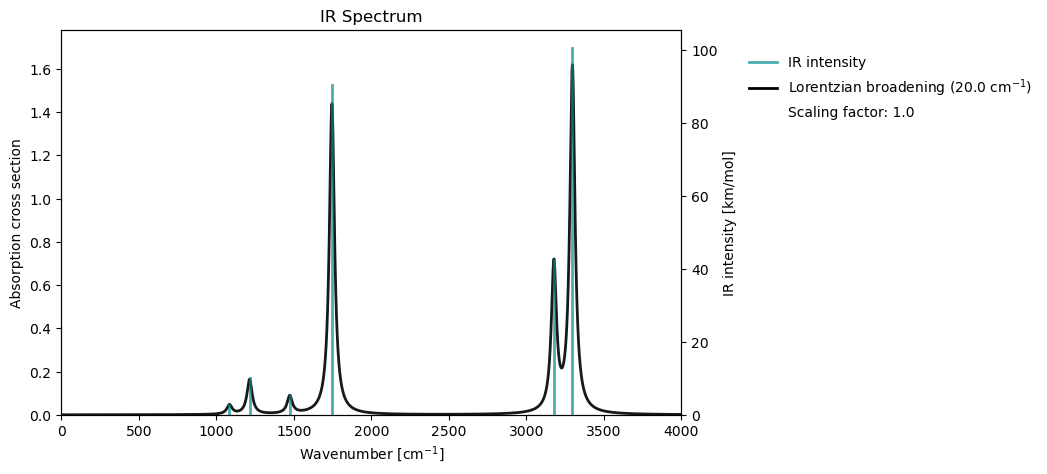

In [2]:
vib_drv.plot_ir(vib_results)

**Text file**

```
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_ir: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                     
@end
```

(sec:raman)=
## Raman

**Python script**

```python
import veloxchem as vlx

xyz="""
... 
"""

molecule = vlx.Molecule.read_xyz_string(xyz)
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.filename = 'mol-raman'
scf_drv.xcfun = 'b3lyp'
results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = False
vib_drv.do_raman = True
vib_drv.filename = 'mol-raman'
vib_results = vib_drv.compute(molecule, basis)
```

**Text file**

```
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_raman: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                     
@end
```

(sec:rrs)=
## Resonance Raman

**Python script**

```python
import veloxchem as vlx

xyz="""
... 
"""

molecule = vlx.Molecule.read_xyz_string(xyz)
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.filename = 'mol-reson-raman'
scf_drv.xcfun = 'b3lyp'
results = scf_drv.compute(molecule, basis)

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = False
vib_drv.do_raman = True
vib_drv.filename = 'mol-reson-raman'
vib_results = vib_drv.compute(molecule, basis)
```

**Text file**

```
@jobs
task: vibrational
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@vibrational
do_resonance_raman: yes
frequencies: 0.05-0.10 (0.05)
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...                      
@end
```